In [1]:
import os # get working directory
import pandas as pd
import numpy as np
import re # regular expression
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.model_selection import KFold
from sklearn.cluster import KMeans

In [2]:
os.getcwd()

'/workspaces/myfolder/project/sasviya_challenge_2026/notebooks'

## Explaratory Data Analysis (EDA)

### Preliminary assessment on train & test set (Python)

In [3]:
hospital_los_train = pd.read_csv("/workspaces/myfolder/project/sasviya_challenge_2026/data/VFL_2026_TRAIN_SET.csv")
hospital_los_train.head(10)

,ENCOUNTER_KEY,PATIENT_NUMBER,DOCTOR,ICU_DAYS,DEPARTMENT,DISCHARGED_TO,STANDARD_ORDERS_USED,NUM_CHRONIC_COND,DISCH_NURSE_ID,ORDER_SET_USED,...,DX_CODE,DX_GROUP,OPERATION_COUNT,MONITORING_HOURS,COMORBIDITY_INDEX,CARE_TEAM_SIZE,HOSPITAL,ADMIT_MTH,NUM_VISITS,ADMIT_LOS
0,300000000,574545941,256444,0,HEART,SKILLED NURSING FACIL,Y,0,2001,1,...,42823,Congestive heart failure; nonhypertensive [108.],1,32,4,4,Hosp 17,4,1,4
1,300000001,700724256,319034,1,HEART,SKILLED NURSING FACIL,N,1,8003,1,...,42823,Congestive heart failure; nonhypertensive [108.],0,0,0,5,Hosp 15,1,0,7
2,300000002,758601585,262051,0,HEART,HOME HEALTH AGENCY,Y,2,497217,1,...,42823,Congestive heart failure; nonhypertensive [108.],1,47,3,3,Hosp 19,2,2,4
3,300000003,660243636,226751,1,PULMONARY,HOME HEALTH AGENCY,Y,1,4002,1,...,4280,Congestive heart failure; nonhypertensive [108.],0,4,0,2,Hosp 14,2,2,5
4,300000004,572184863,284130,3,HEART,SKILLED NURSING FACIL,Y,1,326852,1,...,40491,Hypertension with complications and secondary ...,0,11,2,3,Hosp 32,12,7,4
5,300000005,900024850,220194,0,GENERAL MED,"ROUTINE DSCHG, HOME",Y,4,9004,1,...,486,Pneumonia (except that caused by TB or STD) [1...,0,6,0,1,Hosp 2,4,6,3
6,300000006,613785764,256444,3,PULMONARY,"ROUTINE DSCHG, HOME",N,1,392377,1,...,4821,Pneumonia (except that caused by TB or STD) [1...,1,12,1,1,Hosp 38,11,2,8
7,300000007,942684848,235415,6,HEART,OTHER DEATH,Y,1,360014,1,...,42821,Congestive heart failure; nonhypertensive [108.],1,33,3,4,Hosp 33,8,1,5
8,300000008,856092066,262051,0,HEART,"ROUTINE DSCHG, HOME",Y,2,12005,0,...,42833,Congestive heart failure; nonhypertensive [108.],1,21,3,2,Hosp 2,11,1,3
9,300000009,746216963,275709,0,HEART,"ROUTINE DSCHG, HOME",Y,2,5002,1,...,42841,Congestive heart failure; nonhypertensive [108.],0,5,1,1,Hosp 10,7,6,3


In [4]:
hospital_los_test = pd.read_csv("/workspaces/myfolder/project/sasviya_challenge_2026/data/VFL_2026_TEST_SET.csv")
hospital_los_test.head(10)

,ENCOUNTER_KEY,PATIENT_NUMBER,DOCTOR,ICU_DAYS,DEPARTMENT,DISCHARGED_TO,STANDARD_ORDERS_USED,NUM_CHRONIC_COND,DISCH_NURSE_ID,ORDER_SET_USED,...,PROCEDURE_LONG_DESC,DX_CODE,DX_GROUP,OPERATION_COUNT,MONITORING_HOURS,COMORBIDITY_INDEX,CARE_TEAM_SIZE,HOSPITAL,ADMIT_MTH,NUM_VISITS
0,300100000,553004402,297002,4,HEART,"ROUTINE DSCHG, HOME",Y,2,360014,1,...,INJECTION OF OTHER ANTIINFECTIVE,4280,Congestive heart failure; nonhypertensive [108.],2,68,6,4,Hosp 30,1,1
1,300100001,634863900,235415,0,HEART,"ROUTINE DSCHG, HOME",Y,1,100292,1,...,DIAGNOSTIC ULTRASOUND OF HEART,42843,Congestive heart failure; nonhypertensive [108.],3,67,8,6,Hosp 26,1,1
2,300100002,657483026,235415,10,TRANSPLANT,"ROUTINE DSCHG, HOME",Y,2,6003,0,...,NaN,486,Pneumonia (except that caused by TB or STD) [1...,0,41,3,4,Hosp 10,1,1
3,300100003,922049972,235415,0,HEART,SKILLED NURSING FACIL,Y,0,320013,1,...,DIAGNOSTIC ULTRASOUND OF HEART,4280,Congestive heart failure; nonhypertensive [108.],0,17,0,3,Hosp 21,5,0
4,300100004,609359088,202927,0,HEART,"ROUTINE DSCHG, HOME",Y,4,18007,1,...,NaN,4280,Congestive heart failure; nonhypertensive [108.],0,62,6,4,Hosp 36,11,9
5,300100005,881121257,324306,3,GENERAL MED,"ROUTINE DSCHG, HOME",N,1,340013,0,...,INJECTION OR INFUSION OF OTHER THERAPEUTIC OR ...,42830,Congestive heart failure; nonhypertensive [108.],1,28,2,3,Hosp 37,5,2
6,300100006,671455435,235415,4,HEART,"ROUTINE DSCHG, HOME",Y,2,340013,1,...,DIAGNOSTIC ULTRASOUND OF HEART,42833,Congestive heart failure; nonhypertensive [108.],2,96,3,7,Hosp 27,4,1
7,300100007,589418118,249258,6,HEART,HOME HEALTH AGENCY,N,1,380015,1,...,DIAGNOSTIC ULTRASOUND OF HEART,42823,Congestive heart failure; nonhypertensive [108.],0,0,0,1,Hosp 34,2,2
8,300100008,823248238,306822,4,HEART,HOME HEALTH AGENCY,Y,2,330013,1,...,DIAGNOSTIC ULTRASOUND OF HEART,4280,Congestive heart failure; nonhypertensive [108.],1,46,2,4,Hosp 38,5,0
9,300100009,860760630,218284,13,GENERAL MED,HOSPICE (HOME),Y,1,240010,1,...,INJECTION OF ANTIBIOTIC,486,Pneumonia (except that caused by TB or STD) [1...,0,106,9,8,Hosp 31,6,1


In [5]:
# preliminary dataset assessment for training set - shape, dtypes, missingness, cardinality in one table
def dataset_overview(df, name = "dataset"):
    overview = pd.DataFrame({
        'dtype': df.dtypes,
        'missing_count': df.isna().sum(),
        'missing_percentage': (df.isnull().sum() / len(df) * 100).round(2),
        'unique': df.nunique()
    })
    print(f"{name}: {df.shape[0]} rows, {df.shape[1]} columns\n")
    return overview.sort_values('missing_percentage', ascending = False)

hospital_los_train_overview = dataset_overview(hospital_los_train, "hospital_los_train")
hospital_los_train_overview

hospital_los_train: 100000 rows, 46 columns



,dtype,missing_count,missing_percentage,unique
PROCEDURE_SUBCAT_DESC,object,32072,32.07,25
PROCEDURE_LONG_DESC,object,32072,32.07,64
DOCTOR,int64,0,0.00,98
ICU_DAYS,int64,0,0.00,26
ENCOUNTER_KEY,int64,0,0.00,100000
PATIENT_NUMBER,int64,0,0.00,100000
STANDARD_ORDERS_USED,object,0,0.00,2
NUM_CHRONIC_COND,int64,0,0.00,5
DISCH_NURSE_ID,int64,0,0.00,93
ORDER_SET_USED,int64,0,0.00,2


In [6]:
hospital_los_test_overview = dataset_overview(hospital_los_test, "hospital_los_test")
hospital_los_test_overview

hospital_los_test: 15000 rows, 45 columns



,dtype,missing_count,missing_percentage,unique
PROCEDURE_SUBCAT_DESC,object,4778,31.85,25
PROCEDURE_LONG_DESC,object,4778,31.85,64
DOCTOR,int64,0,0.00,98
PATIENT_NUMBER,int64,0,0.00,15000
ENCOUNTER_KEY,int64,0,0.00,15000
DISCHARGED_TO,object,0,0.00,11
STANDARD_ORDERS_USED,object,0,0.00,2
NUM_CHRONIC_COND,int64,0,0.00,5
DISCH_NURSE_ID,int64,0,0.00,93
ORDER_SET_USED,int64,0,0.00,2


In [7]:
# shows distinct values (including missing) and their counts for a column
def missing_value_breakdown(df, col, name="dataset"):
    value_counts = df[col].value_counts(dropna=False).reset_index()
    value_counts.columns = [col, 'count']
    value_counts['percentage'] = (value_counts['count'] / len(df) * 100).round(2)
    return value_counts

missing_value_breakdown(hospital_los_train, 'PROCEDURE_SUBCAT_DESC', "hospital_los_train")

,PROCEDURE_SUBCAT_DESC,count,percentage
0,NaN,32072,32.07
1,OTHER DIAGNOSTIC RADIOLO,32005,32.01
2,OTHER NONOPERATIVE PROCE,11340,11.34
3,"INCISION, EXCISION, AND",7992,7.99
4,OTHER OPERATIONS ON VESS,3582,3.58
5,NONOPERATIVE INTUBATION,3528,3.53
6,OTHER OPERATIONS ON LUNG,2874,2.87
7,OPERATIONS ON CHEST WALL,1652,1.65
8,"INTERVIEW, EVALUATION, C",1584,1.58
9,NUCLEAR MEDICINE,571,0.57


In [8]:
missing_value_breakdown(hospital_los_test, 'PROCEDURE_SUBCAT_DESC', "hospital_los_test")

,PROCEDURE_SUBCAT_DESC,count,percentage
0,OTHER DIAGNOSTIC RADIOLO,4818,32.12
1,NaN,4778,31.85
2,OTHER NONOPERATIVE PROCE,1683,11.22
3,"INCISION, EXCISION, AND",1195,7.97
4,NONOPERATIVE INTUBATION,538,3.59
5,OTHER OPERATIONS ON VESS,532,3.55
6,OTHER OPERATIONS ON LUNG,426,2.84
7,OPERATIONS ON CHEST WALL,263,1.75
8,"INTERVIEW, EVALUATION, C",226,1.51
9,NUCLEAR MEDICINE,96,0.64


In [9]:
missing_value_breakdown(hospital_los_train, 'PROCEDURE_LONG_DESC', "hospital_los_train")

,PROCEDURE_LONG_DESC,count,percentage
0,NaN,32072,32.07
1,DIAGNOSTIC ULTRASOUND OF HEART,32005,32.01
2,VENOUS CATHETERIZATION NOT ELSEWHERE CLASSIFIED,6912,6.91
3,INJECTION OR INFUSION OF OTHER THERAPEUTIC OR ...,4114,4.11
4,HEMODIALYSIS,3526,3.53
...,...,...,...
60,TRANSFUSION OF PACKED CELLS,57,0.06
61,OTHER ENDOVASCULAR REPAIR OF ANEURYSM OF OTHER...,56,0.06
62,TRANSJUGULAR LIVER BIOPSY,55,0.06
63,VIDEO AND RADIOTELEMETERED ELECTROENCEPHALOGRA...,53,0.05


In [10]:
missing_value_breakdown(hospital_los_test, 'PROCEDURE_LONG_DESC', "hospital_los_test")

,PROCEDURE_LONG_DESC,count,percentage
0,DIAGNOSTIC ULTRASOUND OF HEART,4818,32.12
1,NaN,4778,31.85
2,VENOUS CATHETERIZATION NOT ELSEWHERE CLASSIFIED,1027,6.85
3,INJECTION OR INFUSION OF OTHER THERAPEUTIC OR ...,646,4.31
4,HEMODIALYSIS,517,3.45
...,...,...,...
60,TRANSFUSION OF PACKED CELLS,6,0.04
61,OTHER EXCISION OF PERIANAL TISSUE,6,0.04
62,INSERTION OF OTHER NASOGASTRIC TUBE,5,0.03
63,INJECTION OR INFUSION OF CANCER CHEMOTHERAPEUT...,5,0.03


In [11]:
# checks whether missing desc rows correspond to '.' placeholder in the paired code column -
# confirms "no procedure performed" is a real category, not random missingness
def check_missing_alignment(df, code_col, desc_col, name="dataset"):
    is_missing_desc = df[desc_col].isnull()
    is_placeholder_code = df[code_col] == '.'
    
    aligned = (is_missing_desc == is_placeholder_code).mean() * 100
    print(f"\n{name}: {desc_col} missing aligns with '{code_col} == \".\"' in {aligned:.2f}% of rows")
    
    mismatch = df[is_missing_desc != is_placeholder_code]
    if len(mismatch) > 0:
        print(f"  {len(mismatch)} mismatched row(s)")
    return mismatch

check_missing_alignment(hospital_los_train, 'PROCEDURE_SUBCAT_CODE', 'PROCEDURE_SUBCAT_DESC', "hospital_los_train")


hospital_los_train: PROCEDURE_SUBCAT_DESC missing aligns with 'PROCEDURE_SUBCAT_CODE == "."' in 100.00% of rows


,ENCOUNTER_KEY,PATIENT_NUMBER,DOCTOR,ICU_DAYS,DEPARTMENT,DISCHARGED_TO,STANDARD_ORDERS_USED,NUM_CHRONIC_COND,DISCH_NURSE_ID,ORDER_SET_USED,...,DX_CODE,DX_GROUP,OPERATION_COUNT,MONITORING_HOURS,COMORBIDITY_INDEX,CARE_TEAM_SIZE,HOSPITAL,ADMIT_MTH,NUM_VISITS,ADMIT_LOS


In [12]:
check_missing_alignment(hospital_los_train, 'PROCEDURE_ICD_CODE', 'PROCEDURE_LONG_DESC', "hospital_los_train")


hospital_los_train: PROCEDURE_LONG_DESC missing aligns with 'PROCEDURE_ICD_CODE == "."' in 100.00% of rows


,ENCOUNTER_KEY,PATIENT_NUMBER,DOCTOR,ICU_DAYS,DEPARTMENT,DISCHARGED_TO,STANDARD_ORDERS_USED,NUM_CHRONIC_COND,DISCH_NURSE_ID,ORDER_SET_USED,...,DX_CODE,DX_GROUP,OPERATION_COUNT,MONITORING_HOURS,COMORBIDITY_INDEX,CARE_TEAM_SIZE,HOSPITAL,ADMIT_MTH,NUM_VISITS,ADMIT_LOS


In [13]:
check_missing_alignment(hospital_los_test, 'PROCEDURE_SUBCAT_CODE', 'PROCEDURE_SUBCAT_DESC', "hospital_los_test")


hospital_los_test: PROCEDURE_SUBCAT_DESC missing aligns with 'PROCEDURE_SUBCAT_CODE == "."' in 100.00% of rows


,ENCOUNTER_KEY,PATIENT_NUMBER,DOCTOR,ICU_DAYS,DEPARTMENT,DISCHARGED_TO,STANDARD_ORDERS_USED,NUM_CHRONIC_COND,DISCH_NURSE_ID,ORDER_SET_USED,...,PROCEDURE_LONG_DESC,DX_CODE,DX_GROUP,OPERATION_COUNT,MONITORING_HOURS,COMORBIDITY_INDEX,CARE_TEAM_SIZE,HOSPITAL,ADMIT_MTH,NUM_VISITS


In [14]:
check_missing_alignment(hospital_los_test, 'PROCEDURE_ICD_CODE', 'PROCEDURE_LONG_DESC', "hospital_los_test")


hospital_los_test: PROCEDURE_LONG_DESC missing aligns with 'PROCEDURE_ICD_CODE == "."' in 100.00% of rows


,ENCOUNTER_KEY,PATIENT_NUMBER,DOCTOR,ICU_DAYS,DEPARTMENT,DISCHARGED_TO,STANDARD_ORDERS_USED,NUM_CHRONIC_COND,DISCH_NURSE_ID,ORDER_SET_USED,...,PROCEDURE_LONG_DESC,DX_CODE,DX_GROUP,OPERATION_COUNT,MONITORING_HOURS,COMORBIDITY_INDEX,CARE_TEAM_SIZE,HOSPITAL,ADMIT_MTH,NUM_VISITS


In [15]:
# Flags object columns containing digits-in-text, unusual symbols, or suspicious patterns
def scan_unexpected_characters(df, name="dataset"):
    findings = {}
    obj_cols = df.select_dtypes(include='object').columns
    for col in obj_cols:
        sample = df[col].dropna().astype(str)
        # pattern: embedded hospital-like text, stray symbols, multiple spaces, leading/trailing whitespace
        suspicious = sample[sample.str.contains(r'Hosp \d+|[^\w\s.,()/\-]|  +', regex=True, na=False)]
        if len(suspicious) > 0:
            findings[col] = suspicious.unique()[:5]  # preview up to 5 examples
    print(f"{name}: {len(findings)} column(s) with suspicious patterns")
    for col, examples in findings.items():
        print(f"\n{col}:")
        for ex in examples:
            print(f"  '{ex}'")
    return findings

hospital_los_train_flags = scan_unexpected_characters(hospital_los_train, "hospital_los_train")

hospital_los_train: 7 column(s) with suspicious patterns

DEPARTMENT:
  'Hosp 39'

MS_DRG_DESC:
  'HEART FAILURE & SHOCK W CC'
  'HEART FAILURE & SHOCK W MCC'
  'HEART FAILURE & SHOCK W/O CC/MCC'
  'ECMO OR TRACH W MV 96+ HRS OR PDX EXC FACE, MOUTH & NECK W MAJ O.R.'
  'HEART Hosp 50 OR IMPLANT OF HEART ASSIST SYSTEM W MCC'

DRG_APR_DESC:
  'MAJOR RESPIRATORY INFECTIONS & INFLAMMATIONS'
  'RESPIRATORY SYSTEM DIAGNOSIS W VENTILATOR SUPPORT 96+ HOURS'
  'MALNUTRITION, FAILURE TO THRIVE & OTHER NUTRITIONAL DISORDERS'
  'BRONCHIOLITIS & RSV PNEUMONIA'
  'MAJOR RESPIRATORY & CHEST PROCEDURES'

DIAGNOSIS_SUBCAT_DESC:
  'CHRONIC Hosp 46 HEART'

DIAGNOSIS_LONG_DESC:
  'OTHER CHRONIC Hosp 46 HEART DISEASES'

DX_GROUP:
  'Congestive heart failure; nonhypertensive [108.]'
  'Hypertension with complications and secondary hypertension [99.]'
  'Pneumonia (except that caused by TB or STD) [122.]'
  'Pulmonary heart disease [103.]'
  'Chronic airway obstruction; not otherwise specified'

HOSPITAL:
  

In [16]:
hospital_los_test_flags = scan_unexpected_characters(hospital_los_test, "hospital_los_test")

hospital_los_test: 7 column(s) with suspicious patterns

DEPARTMENT:
  'Hosp 39'

MS_DRG_DESC:
  'HEART FAILURE & SHOCK W MCC'
  'HEART FAILURE & SHOCK W/O CC/MCC'
  'HEART FAILURE & SHOCK W CC'
  'CARDIAC ARRHYTHMIA & CONDUCTION DISORDERS W MCC'
  'ECMO OR TRACH W MV 96+ HRS OR PDX EXC FACE, MOUTH & NECK W MAJ O.R.'

DRG_APR_DESC:
  'SEPTICEMIA & DISSEMINATED INFECTIONS'
  'MAJOR RESPIRATORY INFECTIONS & INFLAMMATIONS'
  'RESPIRATORY SYSTEM DIAGNOSIS W VENTILATOR SUPPORT 96+ HOURS'
  'OTHER RESPIRATORY & CHEST PROCEDURES'
  'BRONCHIOLITIS & RSV PNEUMONIA'

DIAGNOSIS_SUBCAT_DESC:
  'CHRONIC Hosp 46 HEART'

DIAGNOSIS_LONG_DESC:
  'OTHER CHRONIC Hosp 46 HEART DISEASES'

DX_GROUP:
  'Congestive heart failure; nonhypertensive [108.]'
  'Pneumonia (except that caused by TB or STD) [122.]'
  'Hypertension with complications and secondary hypertension [99.]'
  'Septicemia (except in labor) [2.]'
  'Pulmonary heart disease [103.]'

HOSPITAL:
  'Hosp 30'
  'Hosp 26'
  'Hosp 10'
  'Hosp 21'
  'H

In [17]:
# DEPARTMENT corruption check - 'Hosp 39' found spread proportionally across all hospitals,
# not tied to one source, confirming it's a systematic export glitch rather than isolated corruption
print(hospital_los_train['DEPARTMENT'].value_counts())

DEPARTMENT
HEART            54567
GENERAL MED      20576
PULMONARY         7786
ONCOLOGY          7362
TRANSPLANT        6055
Hosp 39           2652
NEUROSCIENCES      452
GENERAL SURG       275
WOMENS             247
PSYCH               28
Name: count, dtype: int64


In [18]:
# DEPARTMENT corruption check - 'Hosp 39' found spread proportionally across all hospitals,
# not tied to one source, confirming it's a systematic export glitch rather than isolated corruption
print(hospital_los_test['DEPARTMENT'].value_counts())

DEPARTMENT
HEART            8217
GENERAL MED      3070
PULMONARY        1191
ONCOLOGY         1041
TRANSPLANT        933
Hosp 39           406
NEUROSCIENCES      76
WOMENS             33
GENERAL SURG       31
PSYCH               2
Name: count, dtype: int64


In [19]:
hospital_los_train[hospital_los_train['DEPARTMENT'] == 'Hosp 39']['HOSPITAL'].value_counts()

HOSPITAL
Hosp 36    86
Hosp 3     84
Hosp 35    77
Hosp 37    76
Hosp 13    76
Hosp 9     75
Hosp 24    75
Hosp 10    74
Hosp 12    74
Hosp 18    73
Hosp 23    72
Hosp 2     72
Hosp 32    72
Hosp 26    72
Hosp 25    72
Hosp 1     71
Hosp 6     71
Hosp 33    70
Hosp 19    70
Hosp 16    70
Hosp 30    69
Hosp 28    69
Hosp 7     69
Hosp 29    68
Hosp 5     68
Hosp 15    68
Hosp 31    67
Hosp 14    66
Hosp 22    65
Hosp 11    65
Hosp 34    63
Hosp 4     63
Hosp 8     63
Hosp 21    62
Hosp 20    60
Hosp 38    51
Hosp 27    51
Hosp 17    50
Hosp 39    33
Name: count, dtype: int64

In [19]:
hospital_los_test[hospital_los_test['DEPARTMENT'] == 'Hosp 39']['HOSPITAL'].value_counts()

HOSPITAL
Hosp 11    18
Hosp 12    16
Hosp 38    16
Hosp 37    16
Hosp 2     15
Hosp 5     14
Hosp 18    13
Hosp 25    13
Hosp 6     12
Hosp 24    12
Hosp 27    12
Hosp 33    12
Hosp 26    11
Hosp 36    11
Hosp 4     11
Hosp 16    11
Hosp 10    11
Hosp 29    11
Hosp 34    10
Hosp 15    10
Hosp 31    10
Hosp 21     9
Hosp 32     9
Hosp 14     9
Hosp 30     9
Hosp 13     9
Hosp 3      9
Hosp 17     9
Hosp 35     9
Hosp 20     9
Hosp 22     8
Hosp 7      7
Hosp 39     7
Hosp 28     7
Hosp 8      7
Hosp 1      7
Hosp 9      6
Hosp 23     6
Hosp 19     5
Name: count, dtype: int64

In [20]:
# DIAGNOSIS_ICD_CODE / DX_CODE redundancy check - confirmed pure duplicate (0 inconsistent mappings)
mapping = hospital_los_train.groupby('DIAGNOSIS_ICD_CODE')['DX_CODE'].nunique()
inconsistent = mapping[mapping > 1]
print(f"{len(inconsistent)} DIAGNOSIS_ICD_CODE value(s) map to multiple DX_CODE values")

0 DIAGNOSIS_ICD_CODE value(s) map to multiple DX_CODE values


In [21]:
# DIAGNOSIS_ICD_CODE / DX_CODE redundancy check - confirmed pure duplicate (0 inconsistent mappings)
mapping = hospital_los_test.groupby('DIAGNOSIS_ICD_CODE')['DX_CODE'].nunique()
inconsistent = mapping[mapping > 1]
print(f"{len(inconsistent)} DIAGNOSIS_ICD_CODE value(s) map to multiple DX_CODE values")

0 DIAGNOSIS_ICD_CODE value(s) map to multiple DX_CODE values


In [22]:
# DIAGNOSIS_GROUP / DX_GROUP relationship check - confirmed genuine subcategory granularity, not redundant
hospital_los_train.groupby('DIAGNOSIS_GROUP')['DX_GROUP'].unique()

DIAGNOSIS_GROUP
AMI     [Pneumonia (except that caused by TB or STD) [...
CHF     [Congestive heart failure; nonhypertensive [10...
COPD    [Obstructive chronic bronchitis, Chronic airwa...
Name: DX_GROUP, dtype: object

In [23]:
# DIAGNOSIS_GROUP / DX_GROUP relationship check - confirmed genuine subcategory granularity, not redundant
hospital_los_test.groupby('DIAGNOSIS_GROUP')['DX_GROUP'].unique()

DIAGNOSIS_GROUP
AMI     [Pneumonia (except that caused by TB or STD) [...
CHF     [Congestive heart failure; nonhypertensive [10...
COPD    [Obstructive chronic bronchitis, Chronic obstr...
Name: DX_GROUP, dtype: object

In [24]:
print(hospital_los_train[hospital_los_train['DIAGNOSIS_GROUP']=='COPD']['DX_GROUP'].unique())

['Obstructive chronic bronchitis'
 'Chronic airway obstruction; not otherwise specified'
 'Other chronic pulmonary disease' 'Emphysema'
 'Chronic obstructive asthma'
 'Pneumonia (except that caused by TB or STD) [122.]']


In [25]:
print(hospital_los_test[hospital_los_test['DIAGNOSIS_GROUP']=='COPD']['DX_GROUP'].unique())

['Obstructive chronic bronchitis' 'Chronic obstructive asthma'
 'Other chronic pulmonary disease' 'Emphysema'
 'Chronic airway obstruction; not otherwise specified'
 'Pneumonia (except that caused by TB or STD) [122.]']


In [26]:
# check distinct values and spelling check for consistency
def distinct_object_values(df, name="dataset", max_display=30):
    obj_cols = df.select_dtypes(include='object').columns
    for col in obj_cols:
        n_unique = df[col].nunique()
        print(f"\n{'='*50}\n{name} — {col} ({n_unique} distinct values)")
        if n_unique <= max_display:
            print(sorted(df[col].dropna().unique()))
        else:
            print(f"(too many to display — showing top 10 by frequency)")
            print(df[col].value_counts().head(10))

distinct_object_values(hospital_los_train, "hospital_los_train")


hospital_los_train — DEPARTMENT (10 distinct values)
['GENERAL MED', 'GENERAL SURG', 'HEART', 'Hosp 39', 'NEUROSCIENCES', 'ONCOLOGY', 'PSYCH', 'PULMONARY', 'TRANSPLANT', 'WOMENS']

hospital_los_train — DISCHARGED_TO (11 distinct values)
['AGNST MEDICAL ADVICE', 'CHG TO LTAC', 'HOME HEALTH AGENCY', 'HOSPICE (HOME)', 'HOSPICE - MEDICAL INP', 'INTERMEDIATE CARE', 'OTHER ACUTE HOSP', 'OTHER DEATH', 'REHAB HOSPITAL', 'ROUTINE DSCHG, HOME', 'SKILLED NURSING FACIL']

hospital_los_train — STANDARD_ORDERS_USED (2 distinct values)
['N', 'Y']

hospital_los_train — GENDER (2 distinct values)
['F', 'M']

hospital_los_train — STATECODE (10 distinct values)
['AL', 'AR', 'FL', 'GA', 'IL', 'MO', 'MS', 'TN', 'TX', 'VA']

hospital_los_train — CITY (163 distinct values)
(too many to display — showing top 10 by frequency)
CITY
Delray Beach       24054
Miami              12389
Hobe Sound          7545
Fort Lauderdale     6594
Canal Point         6265
Loxahatchee         4744
Lake Worth          3797
Orland


hospital_los_train — DIAGNOSIS_LONG_DESC (55 distinct values)
(too many to display — showing top 10 by frequency)
DIAGNOSIS_LONG_DESC
PNEUMONIA ORGANISM UNSPECIFIED                                                                                                                          22213
CONGESTIVE HEART FAILURE UNSPECIFIED                                                                                                                    18960
ACUTE ON CHRONIC DIASTOLIC HEART FAILURE                                                                                                                13680
ACUTE ON CHRONIC SYSTOLIC HEART FAILURE                                                                                                                 13181
ACUTE ON CHRONIC COMBINED SYSTOLIC AND DIASTOLIC HEART FAILURE                                                                                           5085
OBSTRUCTIVE CHRONIC BRONCHITIS WITH ACUTE EXACERBATION                     

In [27]:
distinct_object_values(hospital_los_test, "hospital_los_test")


hospital_los_test — DEPARTMENT (10 distinct values)
['GENERAL MED', 'GENERAL SURG', 'HEART', 'Hosp 39', 'NEUROSCIENCES', 'ONCOLOGY', 'PSYCH', 'PULMONARY', 'TRANSPLANT', 'WOMENS']

hospital_los_test — DISCHARGED_TO (11 distinct values)
['AGNST MEDICAL ADVICE', 'CHG TO LTAC', 'HOME HEALTH AGENCY', 'HOSPICE (HOME)', 'HOSPICE - MEDICAL INP', 'INTERMEDIATE CARE', 'OTHER ACUTE HOSP', 'OTHER DEATH', 'REHAB HOSPITAL', 'ROUTINE DSCHG, HOME', 'SKILLED NURSING FACIL']

hospital_los_test — STANDARD_ORDERS_USED (2 distinct values)
['N', 'Y']

hospital_los_test — GENDER (2 distinct values)
['F', 'M']

hospital_los_test — STATECODE (10 distinct values)
['AL', 'AR', 'FL', 'GA', 'IL', 'MO', 'MS', 'TN', 'TX', 'VA']

hospital_los_test — CITY (163 distinct values)
(too many to display — showing top 10 by frequency)
CITY
Delray Beach       3609
Miami              1917
Hobe Sound         1167
Fort Lauderdale    1006
Canal Point         882
Loxahatchee         704
Lake Worth          584
Orlando            

In [28]:
# duplicate entries checks
def duplicate_check(df, name="dataset"):
    dup_keys = df['ENCOUNTER_KEY'].duplicated().sum()
    dup_rows = df.duplicated().sum()
    print(f"{name}: {dup_keys} duplicate ENCOUNTER_KEY(s), {dup_rows} fully duplicate row(s)")

duplicate_check(hospital_los_train, "hospital_los_train")

hospital_los_train: 0 duplicate ENCOUNTER_KEY(s), 0 fully duplicate row(s)


In [29]:
duplicate_check(hospital_los_test, "hospital_los_test")

hospital_los_test: 0 duplicate ENCOUNTER_KEY(s), 0 fully duplicate row(s)


In [30]:
# assess numerical columns for illogical and outliers e.g. negative age
def numeric_range_check(df, name="dataset"):
    cols_of_interest = [
        'ICU_DAYS', 'NUM_CHRONIC_COND', 'ORDER_TOTAL_CHARGES', 'PATIENT_AGE',
        'OPERATION_COUNT', 'MONITORING_HOURS', 'COMORBIDITY_INDEX', 'CARE_TEAM_SIZE',
        'ADMIT_MTH', 'NUM_VISITS', 'ADMIT_LOS'
    ]
    # only keep columns that actually exist in this df (ADMIT_LOS won't be in test)
    cols_present = [c for c in cols_of_interest if c in df.columns]
    
    ranges = df[cols_present].agg(['min', 'max', 'mean']).T.round(2)
    ranges = ranges.applymap(lambda x: f'{x:,.2f}')
    print(f"\n{name} numeric ranges:")
    return ranges

numeric_range_check(hospital_los_train, "hospital_los_train")


hospital_los_train numeric ranges:


/tmp/ipykernel_455/3818444012.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ranges = ranges.applymap(lambda x: f'{x:,.2f}')


,min,max,mean
ICU_DAYS,0.00,29.00,2.76
NUM_CHRONIC_COND,0.00,4.00,1.03
ORDER_TOTAL_CHARGES,200.00,"100,560.00","21,962.22"
PATIENT_AGE,27.00,101.00,74.43
OPERATION_COUNT,0.00,6.00,0.79
MONITORING_HOURS,0.00,228.00,31.35
COMORBIDITY_INDEX,0.00,19.00,2.66
CARE_TEAM_SIZE,1.00,15.00,3.31
ADMIT_MTH,1.00,12.00,5.94
NUM_VISITS,0.00,31.00,2.46


In [31]:
numeric_range_check(hospital_los_test, "hospital_los_test")


hospital_los_test numeric ranges:


/tmp/ipykernel_455/3818444012.py:12: FutureWarning: DataFrame.applymap has been deprecated. Use DataFrame.map instead.
  ranges = ranges.applymap(lambda x: f'{x:,.2f}')


,min,max,mean
ICU_DAYS,0.00,29.00,2.78
NUM_CHRONIC_COND,0.00,4.00,1.02
ORDER_TOTAL_CHARGES,200.00,"91,950.00","22,124.83"
PATIENT_AGE,27.00,101.00,74.48
OPERATION_COUNT,0.00,6.00,0.79
MONITORING_HOURS,0.00,254.00,31.42
COMORBIDITY_INDEX,0.00,19.00,2.67
CARE_TEAM_SIZE,1.00,14.00,3.32
ADMIT_MTH,1.00,12.00,5.93
NUM_VISITS,0.00,31.00,2.47


In [32]:
# highlight the differences between train and test
def compare_train_test_categories(train_df, test_df, cols):
    for col in cols:
        train_vals = set(train_df[col].dropna().unique())
        test_vals = set(test_df[col].dropna().unique())
        only_in_test = test_vals - train_vals
        print(f"{col}: {len(only_in_test)} value(s) in test not seen in train")
        if only_in_test:
            print(f"  e.g. {list(only_in_test)[:5]}")

high_priority_cols = ['DIAGNOSIS_ICD_CODE', 'PROCEDURE_ICD_CODE', 'MS_DRG_CODE', 
                       'DRG_APR_CODE', 'HOSPITAL', 'DEPARTMENT']
compare_train_test_categories(hospital_los_train, hospital_los_test, high_priority_cols)

DIAGNOSIS_ICD_CODE: 0 value(s) in test not seen in train
PROCEDURE_ICD_CODE: 0 value(s) in test not seen in train
MS_DRG_CODE: 0 value(s) in test not seen in train
DRG_APR_CODE: 0 value(s) in test not seen in train
HOSPITAL: 0 value(s) in test not seen in train
DEPARTMENT: 0 value(s) in test not seen in train


In [33]:
# check for duplicated columns
def check_column_redundancy(df, col_a, col_b, name="dataset"):
    if df[col_a].dtype in ['int64', 'float64'] and df[col_b].dtype in ['int64', 'float64']:
        corr = df[[col_a, col_b]].corr().iloc[0, 1]
        print(f"{name}: correlation({col_a}, {col_b}) = {corr:.3f}")
    else:
        # for code-pair columns, check if mapping is 1:1
        mapping = df.groupby(col_a)[col_b].nunique()
        inconsistent = mapping[mapping > 1]
        print(f"{name}: {col_a} -> {col_b}: {len(inconsistent)} inconsistent mapping(s)")

check_column_redundancy(hospital_los_train, 'DIAGNOSIS_ICD_CODE', 'DX_CODE', "hospital_los_train")
check_column_redundancy(hospital_los_train, 'DIAGNOSIS_GROUP', 'DX_GROUP', "hospital_los_train")
check_column_redundancy(hospital_los_train, 'NUM_CHRONIC_COND', 'COMORBIDITY_INDEX', "hospital_los_train")

hospital_los_train: correlation(DIAGNOSIS_ICD_CODE, DX_CODE) = -0.366
hospital_los_train: DIAGNOSIS_GROUP -> DX_GROUP: 2 inconsistent mapping(s)
hospital_los_train: correlation(NUM_CHRONIC_COND, COMORBIDITY_INDEX) = 0.196


count    100000.000000
mean          5.760090
std           4.167187
min           0.000000
25%           3.000000
50%           5.000000
75%           7.000000
max          51.000000
Name: ADMIT_LOS, dtype: float64

Skewness: 3.26


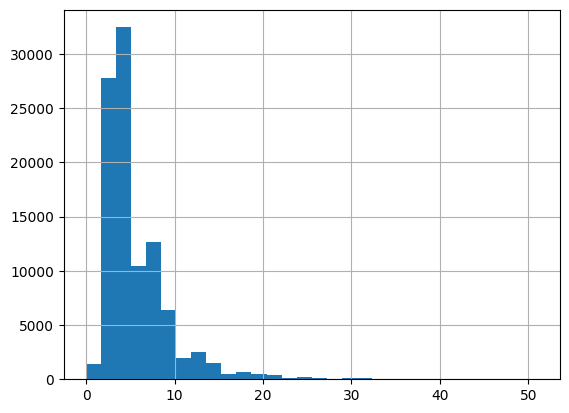

In [34]:
# check ADMIT_LOS data distribution
def target_distribution(df):
    print(df['ADMIT_LOS'].describe())
    print(f"\nSkewness: {df['ADMIT_LOS'].skew():.2f}")
    df['ADMIT_LOS'].hist(bins=30)

target_distribution(hospital_los_train)

In [35]:
# hospital-level resource/operational summary for top-N hospitals by volume
def hospital_resource_summary(df, top_n=10):
    top_hospitals = df['HOSPITAL'].value_counts().head(top_n).index
    subset = df[df['HOSPITAL'].isin(top_hospitals)]
    cols = ['OPERATION_COUNT', 'MONITORING_HOURS', 'ICU_DAYS', 'ORDER_TOTAL_CHARGES', 'CARE_TEAM_SIZE']
    if 'ADMIT_LOS' in df.columns:
        cols.append('ADMIT_LOS')  # only present in train
    return subset.groupby('HOSPITAL')[cols].mean().round(2)

hospital_resource_summary(hospital_los_train)

,OPERATION_COUNT,MONITORING_HOURS,ICU_DAYS,ORDER_TOTAL_CHARGES,CARE_TEAM_SIZE,ADMIT_LOS
HOSPITAL,,,,,,
Hosp 12,0.77,30.97,2.73,21750.83,3.28,5.76
Hosp 16,0.77,31.09,2.76,21721.80,3.30,5.61
Hosp 17,0.82,30.45,2.65,21511.91,3.25,5.67
Hosp 22,0.79,31.89,2.69,21932.88,3.29,5.75
Hosp 26,0.82,31.72,2.78,22416.41,3.34,5.86
Hosp 33,0.80,31.43,2.66,21838.05,3.35,5.75
Hosp 35,0.81,31.92,2.74,22164.75,3.32,5.83
Hosp 36,0.79,32.22,2.85,22018.58,3.37,5.80
Hosp 38,0.77,31.12,2.81,21974.80,3.31,5.81


## Features Transformation

### Continue from SAS pipeline
- one hot encoding transmation
- ensure ADMIT_LOS stays with train set and not in test set to prevent leakage during transformation

In [36]:
hospital_los_train_transformed = pd.read_csv("/workspaces/myfolder/project/sasviya_challenge_2026/data/hospital_los_train_transformed.csv")
hospital_los_train_transformed.head(10)

,ENCOUNTER_KEY,PATIENT_NUMBER,DOCTOR,ICU_DAYS,DEPARTMENT,DISCHARGED_TO,NUM_CHRONIC_COND,DISCH_NURSE_ID,ORDER_SET_USED,ORDER_TOTAL_CHARGES,...,ADMIT_LOS,PROCEDURE_SUBCAT_CODE,PROCEDURE_ICD_CODE,PROCEDURE_SUBCAT_DESC,PROCEDURE_LONG_DESC,had_procedure,STANDARD_ORDERS_USED,high_severity_flag,chronic_burden,STATECODE
0,300088167,786212679,277855,6,PULMONARY,INTERMEDIATE CARE,1,14006,1,43357,...,9,99,99.19,OTHER NONOPERATIVE PROCE,INJECTION OF ANTICOAGULANT,1,1,0,3,VA
1,300091162,923882158,235415,3,HEART,"ROUTINE DSCHG, HOME",1,290012,1,13416,...,5,88,88.72,OTHER DIAGNOSTIC RADIOLO,DIAGNOSTIC ULTRASOUND OF HEART,1,1,0,1,VA
2,300087986,691355721,235415,0,ONCOLOGY,"ROUTINE DSCHG, HOME",1,330013,1,13812,...,6,96,96.71,NONOPERATIVE INTUBATION,CONTINUOUS INVASIVE MECHANICAL VENTILATION FOR...,1,1,1,4,VA
3,300090607,568177739,256444,7,HEART,"ROUTINE DSCHG, HOME",2,236228,1,37106,...,8,88,88.72,OTHER DIAGNOSTIC RADIOLO,DIAGNOSTIC ULTRASOUND OF HEART,1,1,0,10,VA
4,300098151,768750600,287656,0,GENERAL MED,"ROUTINE DSCHG, HOME",1,250010,1,11565,...,2,NONE,NONE,No procedure performed,No procedure performed,0,1,0,1,VA
5,300085298,963686185,297501,1,HEART,"ROUTINE DSCHG, HOME",0,22009,1,33790,...,3,99,99.29,OTHER NONOPERATIVE PROCE,INJECTION OR INFUSION OF OTHER THERAPEUTIC OR ...,1,0,0,0,VA
6,300089288,538200737,292728,0,HEART,HOME HEALTH AGENCY,1,280011,1,17601,...,3,88,88.72,OTHER DIAGNOSTIC RADIOLO,DIAGNOSTIC ULTRASOUND OF HEART,1,1,0,6,VA
7,300091626,643504911,317133,4,HEART,OTHER DEATH,2,3001,0,13691,...,5,99,99.22,OTHER NONOPERATIVE PROCE,INJECTION OF OTHER ANTIINFECTIVE,1,1,0,4,VA
8,300094938,708312274,235415,3,ONCOLOGY,"ROUTINE DSCHG, HOME",0,18007,1,14853,...,5,NONE,NONE,No procedure performed,No procedure performed,0,1,0,3,VA
9,300032885,987754981,220194,5,NEUROSCIENCES,SKILLED NURSING FACIL,1,326852,1,34455,...,10,88,88.72,OTHER DIAGNOSTIC RADIOLO,DIAGNOSTIC ULTRASOUND OF HEART,1,1,1,7,VA


In [37]:
hospital_los_test_transformed = pd.read_csv("/workspaces/myfolder/project/sasviya_challenge_2026/data/hospital_los_test_transformed.csv")
hospital_los_test_transformed.head(10)

,ENCOUNTER_KEY,PATIENT_NUMBER,DOCTOR,ICU_DAYS,DEPARTMENT,DISCHARGED_TO,NUM_CHRONIC_COND,DISCH_NURSE_ID,ORDER_SET_USED,ORDER_TOTAL_CHARGES,...,NUM_VISITS,PROCEDURE_SUBCAT_CODE,PROCEDURE_ICD_CODE,PROCEDURE_SUBCAT_DESC,PROCEDURE_LONG_DESC,had_procedure,STANDARD_ORDERS_USED,high_severity_flag,chronic_burden,STATECODE
0,300103958,983608669,235415,2,HEART,"ROUTINE DSCHG, HOME",2,3001,0,200,...,15,NONE,NONE,No procedure performed,No procedure performed,0,1,0,4,VA
1,300111093,522441641,235415,1,ONCOLOGY,"ROUTINE DSCHG, HOME",1,497217,1,9027,...,2,92,92.29,NUCLEAR MEDICINE,OTHER RADIOTHERAPEUTIC PROCEDURE,1,1,0,1,VA
2,300102017,740921057,344581,3,GENERAL MED,"ROUTINE DSCHG, HOME",1,190916,1,10885,...,9,NONE,NONE,No procedure performed,No procedure performed,0,1,0,2,VA
3,300108959,871503747,306822,1,GENERAL MED,HOME HEALTH AGENCY,1,236228,1,8289,...,1,NONE,NONE,No procedure performed,No procedure performed,0,1,0,3,VA
4,300114930,782241986,262051,2,HEART,"ROUTINE DSCHG, HOME",1,360014,1,26815,...,3,88,88.72,OTHER DIAGNOSTIC RADIOLO,DIAGNOSTIC ULTRASOUND OF HEART,1,1,0,1,VA
5,300100870,976051184,220194,0,PULMONARY,"ROUTINE DSCHG, HOME",1,4002,1,16214,...,2,33,33.24,OTHER OPERATIONS ON LUNG,CLOSED ENDOSCOPIC BIOPSY OF BRONCHUS,1,0,1,6,VA
6,300111104,755126650,262051,0,HEART,HOME HEALTH AGENCY,2,12005,0,16039,...,0,38,38.93,"INCISION, EXCISION, AND",VENOUS CATHETERIZATION NOT ELSEWHERE CLASSIFIED,1,1,0,6,VA
7,300108239,856510026,297048,6,HEART,HOME HEALTH AGENCY,0,280011,1,28490,...,3,88,88.72,OTHER DIAGNOSTIC RADIOLO,DIAGNOSTIC ULTRASOUND OF HEART,1,1,0,3,VA
8,300112580,937562045,297501,2,GENERAL MED,HOME HEALTH AGENCY,1,270011,1,21391,...,1,99,99.19,OTHER NONOPERATIVE PROCE,INJECTION OF ANTICOAGULANT,1,0,0,5,VA
9,300106999,591933492,279187,6,PULMONARY,"ROUTINE DSCHG, HOME",0,21008,1,31061,...,5,38,38.93,"INCISION, EXCISION, AND",VENOUS CATHETERIZATION NOT ELSEWHERE CLASSIFIED,1,1,0,2,VA


In [39]:
print(hospital_los_train_transformed.shape, hospital_los_train_transformed.dtypes)

(100000, 48) ENCOUNTER_KEY              int64
PATIENT_NUMBER             int64
DOCTOR                     int64
ICU_DAYS                   int64
DEPARTMENT                object
DISCHARGED_TO             object
NUM_CHRONIC_COND           int64
DISCH_NURSE_ID             int64
ORDER_SET_USED             int64
ORDER_TOTAL_CHARGES        int64
GENDER                    object
ZIP                        int64
CITY                      object
COUNTY_NAME               object
X                        float64
Y                        float64
REGION                    object
RACE_CD                   object
PATIENT_AGE                int64
DIAGNOSIS_GROUP           object
ICD9_TARGET                int64
MS_DRG_CODE                int64
MS_DRG_DESC               object
DRG_APR_CODE               int64
DRG_APR_DESC              object
DRG_APR_SEVERITY           int64
DIAGNOSIS_SUBCAT_CODE      int64
DIAGNOSIS_SUBCAT_DESC     object
DIAGNOSIS_ICD_CODE       float64
DIAGNOSIS_LONG_DESC       obje

In [40]:
print(hospital_los_test_transformed.shape, hospital_los_test_transformed.dtypes)

(15000, 47) ENCOUNTER_KEY              int64
PATIENT_NUMBER             int64
DOCTOR                     int64
ICU_DAYS                   int64
DEPARTMENT                object
DISCHARGED_TO             object
NUM_CHRONIC_COND           int64
DISCH_NURSE_ID             int64
ORDER_SET_USED             int64
ORDER_TOTAL_CHARGES        int64
GENDER                    object
ZIP                        int64
CITY                      object
COUNTY_NAME               object
X                        float64
Y                        float64
REGION                    object
RACE_CD                   object
PATIENT_AGE                int64
DIAGNOSIS_GROUP           object
ICD9_TARGET                int64
MS_DRG_CODE                int64
MS_DRG_DESC               object
DRG_APR_CODE               int64
DRG_APR_DESC              object
DRG_APR_SEVERITY           int64
DIAGNOSIS_SUBCAT_CODE      int64
DIAGNOSIS_SUBCAT_DESC     object
DIAGNOSIS_ICD_CODE       float64
DIAGNOSIS_LONG_DESC       objec

In [41]:
# K-fold target encoding avoids the leakage risk of plain target encoding (where a category's own row influences its own encoded value
def kfold_target_encode(train_df, test_df, col, target_col='ADMIT_LOS', n_splits=5):
    # Target-encode a categorical column using K-fold to avoid leakage on train
    train_df = train_df.copy()
    test_df = test_df.copy()
    global_mean = train_df[target_col].mean()
    train_df[f'{col}_target_enc'] = global_mean
    
    kf = KFold(n_splits=n_splits, shuffle=True, random_state=42)
    for train_idx, val_idx in kf.split(train_df):
        fold_means = train_df.iloc[train_idx].groupby(col)[target_col].mean()
        train_df.loc[train_df.index[val_idx], f'{col}_target_enc'] = (
            train_df.iloc[val_idx][col].map(fold_means).fillna(global_mean)
        )
    
    # for test, use the full train mapping (no leakage risk since test has no target)
    full_means = train_df.groupby(col)[target_col].mean()
    test_df[f'{col}_target_enc'] = test_df[col].map(full_means).fillna(global_mean)
    
    return train_df, test_df

for col in ['DIAGNOSIS_ICD_CODE', 'PROCEDURE_ICD_CODE', 'MS_DRG_CODE', 'DRG_APR_CODE']:
    hospital_los_train_transformed, hospital_los_test_transformed = kfold_target_encode(hospital_los_train_transformed, hospital_los_test_transformed, col)

In [42]:
# regional density via clustering
coords = hospital_los_train_transformed[['X', 'Y']].values
kmeans = KMeans(n_clusters=15, random_state=42, n_init=10)
hospital_los_train_transformed['geo_cluster'] = kmeans.fit_predict(coords)
hospital_los_test_transformed['geo_cluster'] = kmeans.predict(hospital_los_test_transformed[['X', 'Y']].values)

# distance from each patient's location to their treating hospital's approximate centroid
hospital_centroids = hospital_los_train_transformed.groupby('HOSPITAL')[['X', 'Y']].mean()
hospital_los_train_transformed = hospital_los_train_transformed.merge(hospital_centroids, on='HOSPITAL', suffixes=('', '_hosp_centroid'))
hospital_los_train_transformed['dist_to_hospital'] = np.sqrt(
    (hospital_los_train_transformed['X'] - hospital_los_train_transformed['X_hosp_centroid'])**2 + (hospital_los_train_transformed['Y'] - hospital_los_train_transformed['Y_hosp_centroid'])**2
)

hospital_los_test_transformed = hospital_los_test_transformed.merge(hospital_centroids, on='HOSPITAL', suffixes=('', '_hosp_centroid'))
hospital_los_test_transformed['dist_to_hospital'] = np.sqrt(
    (hospital_los_test_transformed['X'] - hospital_los_test_transformed['X_hosp_centroid'])**2 + (hospital_los_test_transformed['Y'] - hospital_los_test_transformed['Y_hosp_centroid'])**2
)

In [43]:
# drop description columns that carry duplicated encoded codes
desc_cols_to_drop = ['DIAGNOSIS_LONG_DESC', 'MS_DRG_DESC', 'DRG_APR_DESC', 
                      'PROCEDURE_SUBCAT_DESC', 'PROCEDURE_LONG_DESC', 'DIAGNOSIS_SUBCAT_DESC']
hospital_los_train_transformed = hospital_los_train_transformed.drop(columns=desc_cols_to_drop)
hospital_los_test_transformed = hospital_los_test_transformed.drop(columns=desc_cols_to_drop)

In [44]:
# one-hot encoding for low cardinality categoricals
low_card_cols = ['DEPARTMENT', 'GENDER', 'RACE_CD', 'DIAGNOSIS_GROUP', 
                  'DISCHARGED_TO', 'REGION', 'STATECODE']

hospital_los_train_transformed = pd.get_dummies(hospital_los_train_transformed, columns=low_card_cols, drop_first=True)
hospital_los_test_transformed = pd.get_dummies(hospital_los_test_transformed, columns=low_card_cols, drop_first=True)

In [45]:
# align columns in case a category is missing from one set -
# target set aside BEFORE aligning so ADMIT_LOS can never leak into test
y_train_target = hospital_los_train_transformed['ADMIT_LOS']
train_features = hospital_los_train_transformed.drop(columns=['ADMIT_LOS'])
train_features, hospital_los_test_transformed = train_features.align(
    hospital_los_test_transformed, join='left', axis=1, fill_value=0
)
hospital_los_train_transformed = train_features.copy()
hospital_los_train_transformed['ADMIT_LOS'] = y_train_target

In [46]:
# encode medium/high cardinality features
for col in ['HOSPITAL', 'DX_GROUP', 'DIAGNOSIS_SUBCAT_CODE']:
    hospital_los_train_transformed, hospital_los_test_transformed = kfold_target_encode(hospital_los_train_transformed, hospital_los_test_transformed, col)

In [47]:
# drop CITY, COUNTY_NAME, ZIP and keep the remaining geographic features
hospital_los_train_transformed = hospital_los_train_transformed.drop(columns=['CITY', 'COUNTY_NAME', 'ZIP'])
hospital_los_test_transformed = hospital_los_test_transformed.drop(columns=['CITY', 'COUNTY_NAME', 'ZIP'])

In [48]:
# drop raw code columns as target-encoded versions exist
raw_code_cols = ['DIAGNOSIS_ICD_CODE', 'PROCEDURE_ICD_CODE', 'MS_DRG_CODE', 
                  'DRG_APR_CODE', 'HOSPITAL', 'DX_GROUP', 'DIAGNOSIS_SUBCAT_CODE',
                  'PROCEDURE_SUBCAT_CODE']

hospital_los_train_transformed = hospital_los_train_transformed.drop(columns=raw_code_cols)
hospital_los_test_transformed = hospital_los_test_transformed.drop(columns=raw_code_cols)

In [49]:
# drop ID columns and centroid intermediates not needed as model features;
# keep ENCOUNTER_KEY aside separately for the final submission mapping
non_feature_cols = ['ENCOUNTER_KEY', 'PATIENT_NUMBER', 'DOCTOR', 'DISCH_NURSE_ID',
                     'X_hosp_centroid', 'Y_hosp_centroid']

train_encounter_keys = hospital_los_train_transformed['ENCOUNTER_KEY']
test_encounter_keys = hospital_los_test_transformed['ENCOUNTER_KEY']

hospital_los_train_transformed = hospital_los_train_transformed.drop(columns=non_feature_cols)
hospital_los_test_transformed = hospital_los_test_transformed.drop(columns=non_feature_cols) 

In [50]:
# captures compounding effect of ICU time and diagnosis severity on LOS
hospital_los_train_transformed['icu_x_severity'] = hospital_los_train_transformed['ICU_DAYS'] * hospital_los_train_transformed['DRG_APR_SEVERITY']
hospital_los_test_transformed['icu_x_severity'] = hospital_los_test_transformed['ICU_DAYS'] * hospital_los_test_transformed['DRG_APR_SEVERITY']

# captures whether frequent visitors with more chronic conditions show a distinct LOS pattern
hospital_los_train_transformed['visits_x_chronic'] = hospital_los_train_transformed['NUM_VISITS'] * hospital_los_train_transformed['NUM_CHRONIC_COND']
hospital_los_test_transformed['visits_x_chronic'] = hospital_los_test_transformed['NUM_VISITS'] * hospital_los_test_transformed['NUM_CHRONIC_COND']

# captures compounding effect of ICU time and overall comorbidity burden on LOS
hospital_los_train_transformed['icu_x_comorbidity'] = hospital_los_train_transformed['ICU_DAYS'] * hospital_los_train_transformed['COMORBIDITY_INDEX']
hospital_los_test_transformed['icu_x_comorbidity'] = hospital_los_test_transformed['ICU_DAYS'] * hospital_los_test_transformed['COMORBIDITY_INDEX']

# captures whether staffing intensity scales appropriately with patient complexity
hospital_los_train_transformed['careteam_x_comorbidity'] = hospital_los_train_transformed['CARE_TEAM_SIZE'] * hospital_los_train_transformed['COMORBIDITY_INDEX']
hospital_los_test_transformed['careteam_x_comorbidity'] = hospital_los_test_transformed['CARE_TEAM_SIZE'] * hospital_los_test_transformed['COMORBIDITY_INDEX']

# captures compounding effect of age and comorbidity burden (frailty) on LOS
hospital_los_train_transformed['comorbidity_x_age'] = hospital_los_train_transformed['COMORBIDITY_INDEX'] * hospital_los_train_transformed['PATIENT_AGE']
hospital_los_test_transformed['comorbidity_x_age'] = hospital_los_test_transformed['COMORBIDITY_INDEX'] * hospital_los_test_transformed['PATIENT_AGE']

# age group (binned), kept alongside continuous PATIENT_AGE
# useful for linear models, capture non-linear age effects that a raw coefficient can't
age_bins = [0, 40, 55, 65, 75, 85, 120]
age_labels = ['under_40', '40_54', '55_64', '65_74', '75_84', '85_plus']
hospital_los_train_transformed['age_group'] = pd.cut(hospital_los_train_transformed['PATIENT_AGE'], bins=age_bins, labels=age_labels)
hospital_los_test_transformed['age_group'] = pd.cut(hospital_los_test_transformed['PATIENT_AGE'], bins=age_bins, labels=age_labels)

# age_group needs one-hot encoding since it's categorical
hospital_los_train_transformed = pd.get_dummies(hospital_los_train_transformed, columns=['age_group'], drop_first=True)
hospital_los_test_transformed = pd.get_dummies(hospital_los_test_transformed, columns=['age_group'], drop_first=True)

In [ ]:
# align again after age_group encoding - to prevent leakage
y_train_target = hospital_los_train_transformed['ADMIT_LOS']
train_features = hospital_los_train_transformed.drop(columns=['ADMIT_LOS'])
train_features, hospital_los_test_transformed = train_features.align(
    hospital_los_test_transformed, join='left', axis=1, fill_value=0
)
hospital_los_train_transformed = train_features.copy()
hospital_los_train_transformed['ADMIT_LOS'] = y_train_target

In [52]:
print('ADMIT_LOS' in hospital_los_train_transformed.columns, 'ADMIT_LOS' in hospital_los_test_transformed.columns)
print(hospital_los_train_transformed.columns.tolist())
print(hospital_los_test_transformed.columns.tolist())

True False
['ICU_DAYS', 'NUM_CHRONIC_COND', 'ORDER_SET_USED', 'ORDER_TOTAL_CHARGES', 'X', 'Y', 'PATIENT_AGE', 'ICD9_TARGET', 'DRG_APR_SEVERITY', 'OPERATION_COUNT', 'MONITORING_HOURS', 'COMORBIDITY_INDEX', 'CARE_TEAM_SIZE', 'ADMIT_MTH', 'NUM_VISITS', 'had_procedure', 'STANDARD_ORDERS_USED', 'high_severity_flag', 'chronic_burden', 'DIAGNOSIS_ICD_CODE_target_enc', 'PROCEDURE_ICD_CODE_target_enc', 'MS_DRG_CODE_target_enc', 'DRG_APR_CODE_target_enc', 'geo_cluster', 'dist_to_hospital', 'DEPARTMENT_GENERAL SURG', 'DEPARTMENT_HEART', 'DEPARTMENT_NEUROSCIENCES', 'DEPARTMENT_ONCOLOGY', 'DEPARTMENT_PSYCH', 'DEPARTMENT_PULMONARY', 'DEPARTMENT_TRANSPLANT', 'DEPARTMENT_Unknown', 'DEPARTMENT_WOMENS', 'GENDER_M', 'RACE_CD_Others', 'RACE_CD_White', 'DIAGNOSIS_GROUP_CHF', 'DIAGNOSIS_GROUP_COPD', 'DISCHARGED_TO_CHG TO LTAC', 'DISCHARGED_TO_HOME HEALTH AGENCY', 'DISCHARGED_TO_HOSPICE (HOME)', 'DISCHARGED_TO_HOSPICE - MEDICAL INP', 'DISCHARGED_TO_INTERMEDIATE CARE', 'DISCHARGED_TO_OTHER ACUTE HOSP', 'DISCH

In [54]:
hospital_los_train_transformed.head(5)

,ICU_DAYS,NUM_CHRONIC_COND,ORDER_SET_USED,ORDER_TOTAL_CHARGES,X,Y,PATIENT_AGE,ICD9_TARGET,DRG_APR_SEVERITY,OPERATION_COUNT,...,visits_x_chronic,icu_x_comorbidity,careteam_x_comorbidity,comorbidity_x_age,age_group_40_54,age_group_55_64,age_group_65_74,age_group_75_84,age_group_85_plus,ADMIT_LOS
0,6,1,1,43357,-77.18702,38.773578,81,0,2,1,...,2,12,2,162,False,False,False,True,False,9
1,3,1,1,13416,-77.18702,38.773578,76,1,2,0,...,2,0,0,0,False,False,False,True,False,5
2,0,1,1,13812,-77.18702,38.773578,87,1,4,1,...,2,0,9,261,False,False,False,False,True,6
3,7,2,1,37106,-77.18702,38.773578,69,1,3,1,...,2,56,40,552,False,False,True,False,False,8
4,0,1,1,11565,-77.18702,38.773578,81,1,2,0,...,4,0,0,0,False,False,False,True,False,2


In [53]:
hospital_los_train_transformed.to_csv("/workspaces/myfolder/project/sasviya_challenge_2026/data/hospital_los_train_final.csv",index = False)
hospital_los_test_transformed.to_csv("/workspaces/myfolder/project/sasviya_challenge_2026/data/hospital_los_test_final.csv",index = False)